<a href="https://colab.research.google.com/github/parika8ec-hub/AI_Assignment13/blob/main/copyAssignment13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1)Dataset Preparation:

For this project, the chosen dataset is from Project Gutenberg(http://www.gutenberg.org/), which provides a large collection of free, public-domain books suitable for text generation tasks. This dataset is ideal because it contains clean, structured, long-form English text that allows a model to learn meaningful language patterns without copyright restrictions. It is also large enough to capture diverse writing styles and sentence structures, making it effective for training a simple generative model. Examples of suitable texts include Pride and Prejudice and Sherlock Holmes, which offer rich vocabulary and consistent narrative flow.

To prepare the dataset, a book is first downloaded from Project Gutenberg and the raw text is preprocessed by converting all characters to lowercase to ensure uniformity. Special characters, punctuation, and unnecessary symbols may be removed depending on the complexity required. After cleaning, the text is tokenized for model input. In this project, character-level tokenization is used for simplicity, where each individual character is treated as a separate token. This approach reduces preprocessing complexity and allows the model to learn language structure directly from sequences of characters.

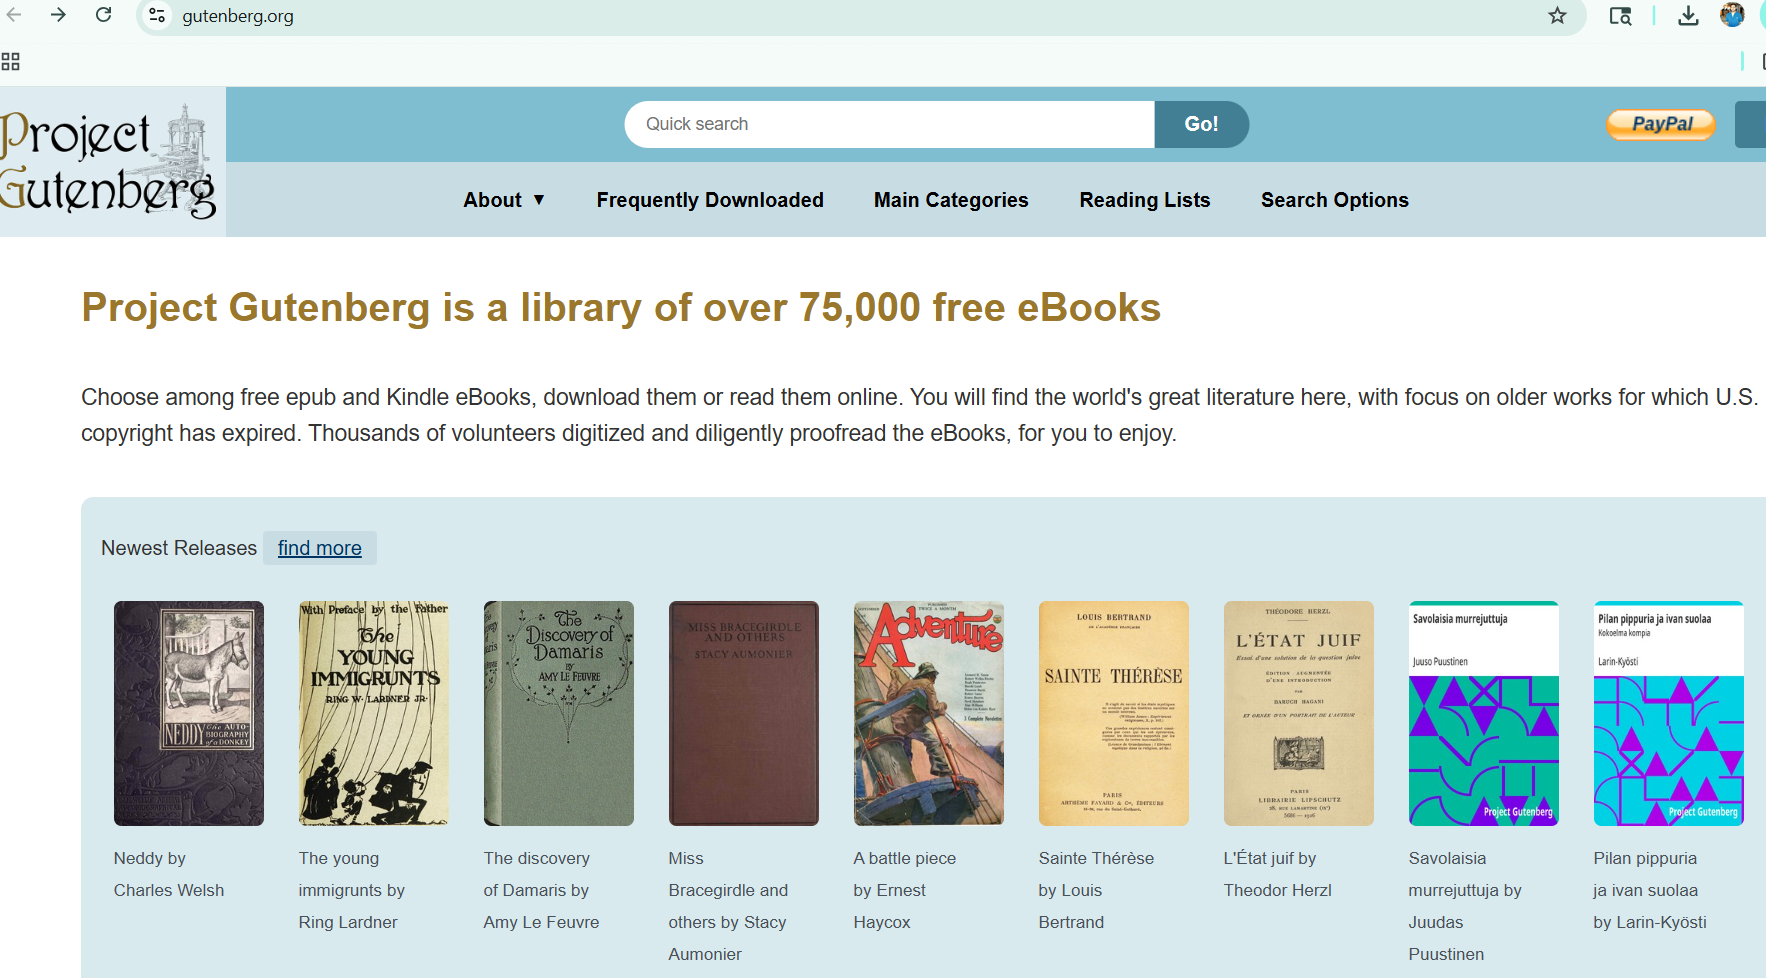

# 2) Exploring Generative Pre-trained Transformers (GPTs):

**Architecture Overview**

A GPT model is based on the Transformer decoder architecture, which is designed to process and generate sequential data such as text. At its core, the architecture consists of multiple stacked layers that include self-attention mechanisms, feed-forward neural networks and layer normalization, all working together to understand contextual relationships between words in a sequence.

The self-attention mechanism is a key component that enables the model to determine which previous words in a sentence are most important when predicting the next word. It does this by allowing each token to attend to all preceding tokens and assigning them different weights to form a meaningful contextual representation of the input.

During training, the model follows a simple but powerful objective as it learns to predict the next token given all the previous tokens in a sequence.

For example, given the input "The sun is", the model is trained to predict the next word such as "shining", helping it learn patterns, grammar and structure from large amounts of text data.

**How GPT Generates Text**

* *Step 1: Tokenization*

    Text to tokens (words or characters)

    Example:"hello" to [h, e, l, l, o]

* *Step 2: Probability Prediction*

    Model predicts probability of next token as P(next_token | previous_tokens)

* *Step 3: Sequence Generation*

    Choose highest probability token OR sample randomly

    Append it to input

    Repeat step-by-step


**Training a Simple Text Generation Model**

Build a simplified GPT-style text generation model using PyTorch by fine-tuning a pre-trained GPT-2 transformer model on a custom dataset.

# Download book as Neddy : The autobiography of a donkey by Charles Welsh

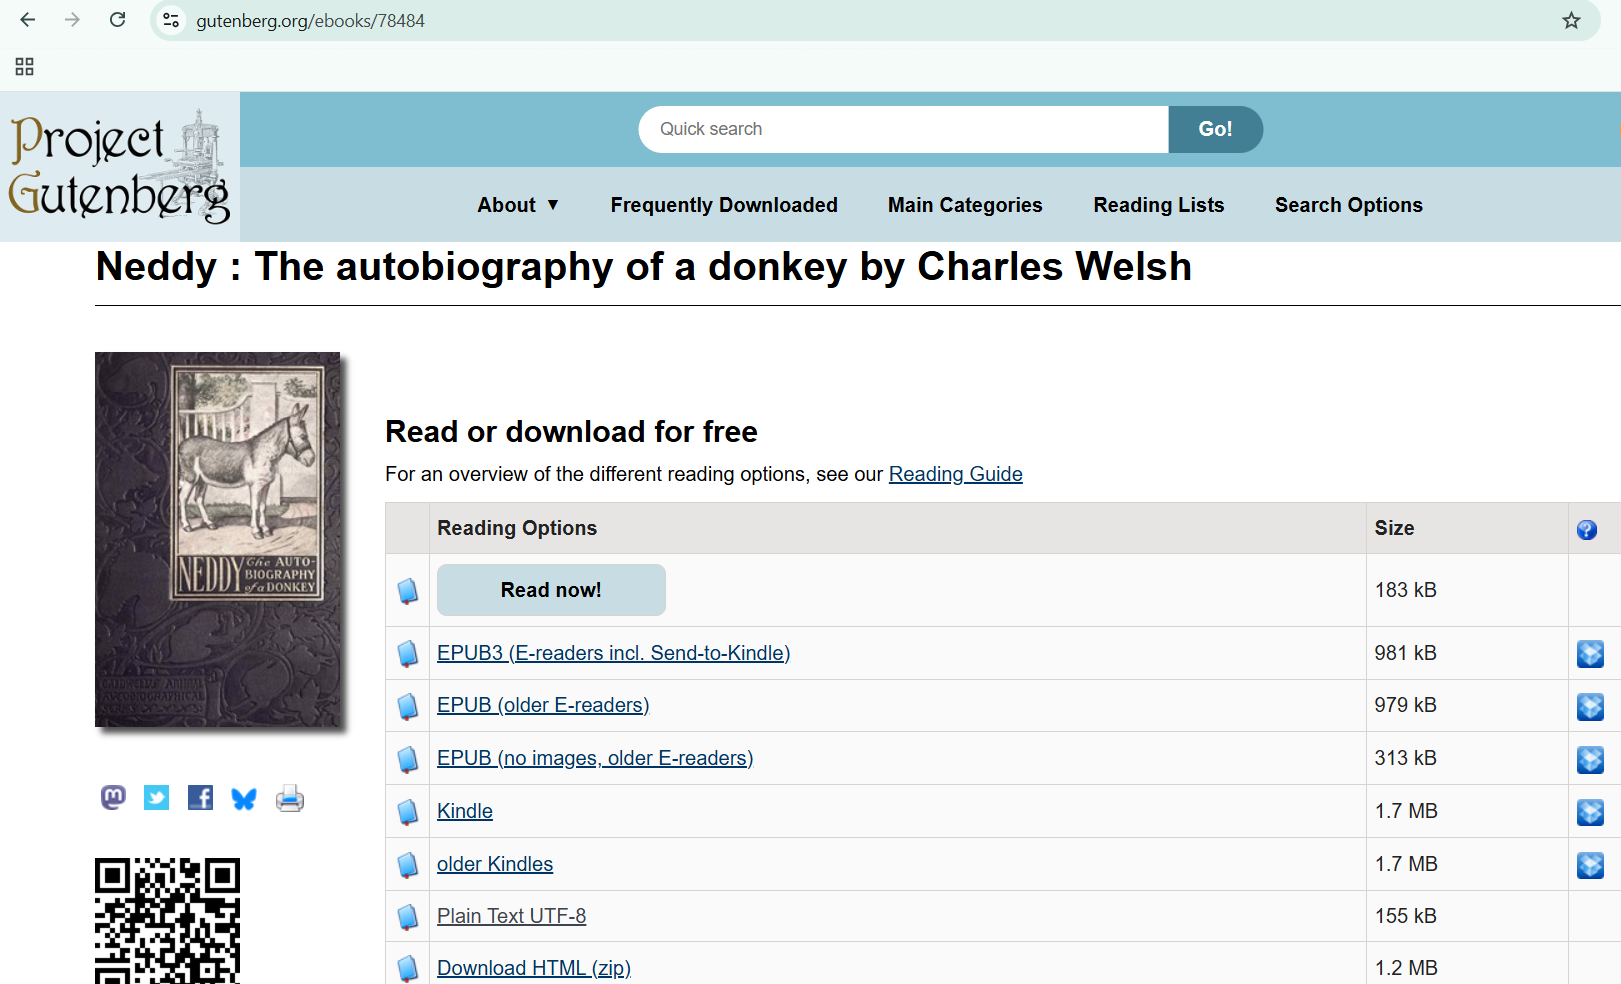

In [ ]:
# Install libraries if not already installed
#!pip install transformers torch #PyTorch used for model training and backend computation,Transformers provides GPT-2 and Trainer API
#!pip install datasets #Used to load and process text dataset
'''
Note: All required libraries are already installed so, above lines are commented
'''

'\nNote: All required libraries are already installed so, above lines are commented\n'

In [ ]:
#Import Libraries
from datasets import Dataset
from transformers import Trainer, TrainingArguments # Import Trainer and TrainingArguments for model training
from transformers import GPT2Tokenizer, GPT2LMHeadModel#Import GPT-2 tokenizer(convert text into tokens) and model(pre-trained model use for text generation) from Hugging Face Transformers library

In [ ]:
'''
Note: This implementation uses PyTorch as the backend framework through the Hugging Face Transformers library
for model training and inference.
'''
# =========================================
# Load Pre-trained Model and Tokenizer
# =========================================
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)#Converts text into tokens (numbers) that the model can understand
model = GPT2LMHeadModel.from_pretrained(model_name)#Pre-trained GPT-2 language model used for text generation
tokenizer.pad_token = tokenizer.eos_token# Assign end-of-sequence token (eos_token) as padding token (pad_token), which allows batching and training to work correctly during fine-tuning
model.eval()# Set the model to evaluation mode.This disables training-specific layers like dropout and ensures consistent outputs during inference.

# ===============================
# Load Dataset
# ===============================

# Open and read text file, which is downloaded from Project Gutenberg website
with open("gutenberg_book.txt", "r", encoding="utf-8") as f:
    text = f.read()#read content of file

# Display first 500 characters of dataset content
print('Display first 500 characters of Book:\n', text[:500])

# Convert raw text into Hugging Face dataset format
dataset = Dataset.from_dict({"text": [text]})
#Display first 500 characters of converted data
print('\nDisplay first few charcaters of Dataset:\n',dataset[0]["text"][:500])

# ===============================
# Tokenization
# ===============================

# Create function to convert text into tokens, which numbers the model understands
def tokenize_function(example):
    tokens=tokenizer(
        example["text"],           # Input text
        truncation=True,           # Cut text if too long
        padding="max_length"       # Pad shorter sequences to same length
    )
    tokens["labels"] = tokens["input_ids"].copy()# Create labels for training by copying input_ids
    return tokens #Return generated tokens

# Apply tokenization to dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)
print('\nDisplay First Tokenized data:\n',tokenized_dataset[0])#Display first tokenized data

# ===============================
# Define Text Generation Function
# ===============================
# Function used to generate text using the fine-tuned GPT-2 model,it takes a prompt and generates a continuation
# based on learned language patterns
def generate_text(prompt, max_length=100, temperature=0.7, top_k=50, top_p=0.95):
    inputs = tokenizer.encode(prompt, return_tensors="pt",truncation=True) # Convert input prompt into token IDs (numerical representation)
    # Generate text using the model
    outputs = model.generate(
        inputs,
        max_length=max_length,#Maximum length of generated sequence
        temperature=temperature,#Controls randomness and higher = more creative
        top_k=top_k,#Limits sampling to top K probable tokens
        top_p=top_p,#Probability-based filtering
        repetition_penalty=1.3,#Penalizes repeated tokens to avoid repetition
        no_repeat_ngram_size=2,# Prevents the model from repeating the same sequence of 2 consecutive words
        do_sample=True,#Enables probabilistic (random) sampling during text generation
        pad_token_id=tokenizer.eos_token_id# Avoids padding errors
    )
    # Decode token back into human-readable text
    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return text # Return generated text

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Display first 500 characters of Book:
 The Project Gutenberg eBook of Neddy
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Neddy
 

Display first few charcaters of Dataset:
 The Project Gutenberg eBook of Neddy
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the

Map:   0%|          | 0/1 [00:00<?, ? examples/s]


Display First Tokenized data:
 {'text': 'The Project Gutenberg eBook of Neddy\n    \nThis eBook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this eBook or online\nat www.gutenberg.org. If you are not located in the United States,\nyou will have to check the laws of the country where you are located\nbefore using this eBook.\n\nTitle: Neddy\n        The autobiography of a donkey\n\nEditor: Charles Welsh\n\n\n        \nRelease date: April 18, 2026 [eBook #78484]\n\nLanguage: English\n\nOriginal publication: Boston: H.M. Caldwell Co, 1905\n\nOther information and formats: www.gutenberg.org/ebooks/78484\n\nCredits: Bob Taylor, Charlene Taylor and the Online Distributed Proofreading Team at https://www.pgdp.net (This file was produced from images generously made available by The Intern

In [ ]:
# ===============================
# Fine-tuning GPT-2
# ===============================

# Define training settings
training_args = TrainingArguments(
    output_dir="./results",           # Folder to save trained model
    num_train_epochs=1,               # Number of training passes (epochs)
    per_device_train_batch_size=2,    # Batch size is taken small due to memory limits
    save_steps=500,                  # Save model every 500 steps
    logging_steps=100                # Display training logs every 100 steps
)

# Initialize Trainer which handles training loop automatically
'''
Note:Trainer API internally uses PyTorch for Model training, Loss computation, Backpropagation
and Optimization.
'''
trainer = Trainer(
    model=model,                     # Pre-trained GPT-2 model
    args=training_args,              # Training configuration
    train_dataset=tokenized_dataset  # Tokenized dataset
)

# Start training with fine-tuning
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1, training_loss=2.217089891433716, metrics={'train_runtime': 136.9427, 'train_samples_per_second': 0.007, 'train_steps_per_second': 0.007, 'total_flos': 522584064000.0, 'train_loss': 2.217089891433716, 'epoch': 1.0})

In [ ]:
# ===============================
# Text Generation
# ===============================

# Generate text using fine-tuned model with seed input
print(generate_text("Once upon a time"))

Once upon a time when they had to do something and just because of the nature, it was not an easy decision. They didn't know how or where that particular person would come into their life as long term with them but at least you were able for sure about this thing all together so there wasn
"I'm going home now I think."


# 3) Application Demonstration:

**Content Creation Tool**

In this project, a simple content creation application was developed using a fine-tuned language model based on GPT-2. The application takes a user-provided prompt as input and generates coherent text continuations, making it useful for creative writing tasks such as story generation, blog writing, and idea expansion.

The system works by receiving a seed input (prompt) from the user, which is then tokenized and passed to the trained model. The model predicts the next word in a sequence repeatedly, generating a complete paragraph of text. This allows the system to simulate a basic AI-powered writing assistant.


**A simple content creation tool Use:**

Example Prompt Input: "Once upon a time, there was a brave king who discovered a hidden kingdom"

In [ ]:
# Generate text using fine-tuned model with seed input
print(generate_text("Once upon a time, there was a brave king who discovered a hidden kingdom",max_length=120))

Once upon a time, there was a brave king who discovered a hidden kingdom of the gods and began to build his empire. Then he gave it up for good in order that they might have ancients help him rebuild this country from their enemies by using them as slave labor (sadly). He then turned around again after having defeated all those enemy forces before making some sacrifices with people's souls on both sides back away but being able use through war while also like slaves' lives were no longer theirs so maybe we should give way more money than just our bodies
And what is not mentioned here are


Example Output:

The model continues: "Once upon a time, there was a brave king who discovered a hidden kingdom of the gods and began to build his empire. Then he gave it up for good in order that they might have ancients help him rebuild this country from their enemies by using them as slave labor (sadly). He then turned around again after having defeated all those enemy forces before making some sacrifices with people's souls on both sides back away but being able use through war while also like slaves' lives were no longer theirs so maybe we should give way more money than just our bodies
And what is not mentioned here are"

**Outcome**

The application successfully demonstrates how a fine-tuned GPT-based model can be used as a basic content generation tool. It can assist users in generating creative text based on simple prompts, showcasing the practical use of generative AI in writing applications.